# PC Causal Discovery Demo

| Overview row | Method | Teaching point |
|---|---|---|
| Constraint-based | PC | Conditional independence can orient a collider. |

Physical story: ad spend and good weather are independent external causes of demand. PC should find two arrows into demand and no edge between the two causes.

In [ ]:
!pip3 install -q git+https://github.com/NetManAIOps/sktime.git causal-learn matplotlib

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch

from sktime.causal_discovery import PC

In [28]:
rng = np.random.default_rng(12)
n = 1200

ad_spend = rng.normal(size=n)
weather = rng.normal(size=n)
demand = 0.90 * ad_spend + 0.80 * weather + rng.normal(scale=0.55, size=n)

X = pd.DataFrame({"AdSpend": ad_spend, "Weather": weather, "Demand": demand})
X = (X - X.mean()) / X.std()

TRUE_EDGES = {("AdSpend", "Demand"), ("Weather", "Demand")}
NODES = ["AdSpend", "Weather", "Demand"]
POSITIONS = {"AdSpend": (0, 1), "Weather": (0, -1), "Demand": (1.4, 0)}

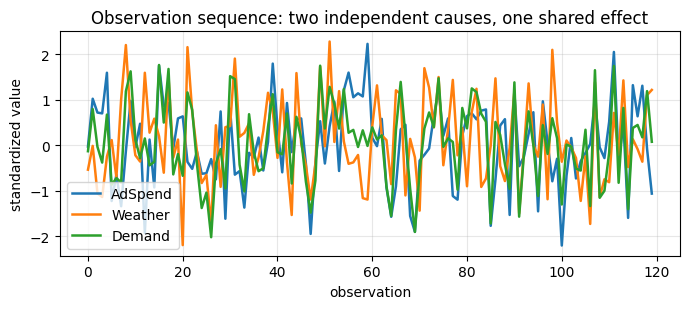

In [29]:
ax = X.iloc[:120].plot(figsize=(7, 3.2), linewidth=1.8)
ax.set_title("Observation sequence: two independent causes, one shared effect")
ax.set_xlabel("observation")
ax.set_ylabel("standardized value")
ax.grid(alpha=0.3)
plt.tight_layout()

In [30]:
X.corr().round(2)

,AdSpend,Weather,Demand
AdSpend,1.00,0.00,0.68
Weather,0.00,1.00,0.61
Demand,0.68,0.61,1.00


In [31]:
COLORS = {
    "correct": "#2ca02c",
    "false positive": "#d62728",
    "missed": "#8c8c8c",
    "ambiguous": "#ff7f0e",
}


def status_for_edge(source, target, kind, true_edges):
    if kind == "directed" and (source, target) in true_edges:
        return "correct"
    if kind == "undirected" and ((source, target) in true_edges or (target, source) in true_edges):
        return "ambiguous"
    if (target, source) in true_edges:
        return "ambiguous"
    return "false positive"


def covered_true_edges(pred_edges, true_edges):
    covered = set()
    for source, target, kind in pred_edges:
        if (source, target) in true_edges:
            covered.add((source, target))
        if kind == "undirected" and (target, source) in true_edges:
            covered.add((target, source))
    return covered


def edge_table(pred_edges, true_edges):
    rows = []
    for source, target, kind in pred_edges:
        rows.append(
            {
                "source": source,
                "target": target,
                "type": kind,
                "status": status_for_edge(source, target, kind, true_edges),
            }
        )
    for source, target in sorted(true_edges - covered_true_edges(pred_edges, true_edges)):
        rows.append(
            {"source": source, "target": target, "type": "true edge", "status": "missed"}
        )
    return pd.DataFrame(rows)


def cpdag_edge_list(adjacency, names):
    edges = []
    for i, source in enumerate(names):
        for j, target in enumerate(names):
            if adjacency[i, j] == 1:
                edges.append((source, target, "directed"))
    for i, source in enumerate(names):
        for j, target in enumerate(names):
            if i < j and adjacency[i, j] == -1 and adjacency[j, i] == -1:
                edges.append((source, target, "undirected"))
    return edges


def score_edges(pred_edges, true_edges):
    table = edge_table(pred_edges, true_edges)
    return table["status"].value_counts().reindex(
        ["correct", "ambiguous", "false positive", "missed"], fill_value=0
    )


def draw_edge(ax, source, target, color, positions, node_artists, kind="directed", linestyle="-", rad=0.03):
    arrowstyle = "-|>" if kind == "directed" else "<|-|>"
    patch = FancyArrowPatch(
        positions[source],
        positions[target],
        arrowstyle=arrowstyle,
        mutation_scale=16,
        linewidth=2.5,
        color=color,
        linestyle=linestyle,
        connectionstyle=f"arc3,rad={rad}",
        patchA=node_artists[source].get_bbox_patch(),
        patchB=node_artists[target].get_bbox_patch(),
        shrinkA=7,
        shrinkB=7,
        zorder=2,
    )
    ax.add_patch(patch)


def draw_causal_graph(ax, nodes, positions, pred_edges, true_edges, title):
    node_artists = {}
    for node in nodes:
        x, y = positions[node]
        node_artists[node] = ax.text(
            x,
            y,
            node,
            ha="center",
            va="center",
            fontsize=10.5,
            zorder=3,
            bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "black", "lw": 1.2},
        )
    ax.figure.canvas.draw()

    for source, target in true_edges - covered_true_edges(pred_edges, true_edges):
        draw_edge(ax, source, target, COLORS["missed"], positions, node_artists, linestyle="--", rad=-0.06)

    for source, target, kind in pred_edges:
        status = status_for_edge(source, target, kind, true_edges)
        draw_edge(ax, source, target, COLORS[status], positions, node_artists, kind=kind)

    xs = [p[0] for p in positions.values()]
    ys = [p[1] for p in positions.values()]
    ax.set_xlim(min(xs) - 0.55, max(xs) + 0.55)
    ax.set_ylim(min(ys) - 0.65, max(ys) + 0.65)
    ax.set_title(title)
    ax.axis("off")


def plot_causal_graph(nodes, positions, pred_edges, true_edges, title):
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    draw_causal_graph(ax, nodes, positions, pred_edges, true_edges, title)
    add_graph_legend(fig)
    plt.tight_layout()


def plot_graph_comparison(nodes, positions, left_edges, right_edges, true_edges, left_title, right_title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    draw_causal_graph(axes[0], nodes, positions, left_edges, true_edges, left_title)
    draw_causal_graph(axes[1], nodes, positions, right_edges, true_edges, right_title)
    add_graph_legend(fig)
    plt.tight_layout()


def add_graph_legend(fig):
    legend = [
        Line2D([0], [0], color=COLORS["correct"], lw=3, label="correct directed edge"),
        Line2D([0], [0], color=COLORS["ambiguous"], lw=3, label="ambiguous orientation"),
        Line2D([0], [0], color=COLORS["false positive"], lw=3, label="false positive"),
        Line2D([0], [0], color=COLORS["missed"], lw=3, ls="--", label="missed true edge"),
    ]
    fig.legend(handles=legend, loc="lower center", ncol=4, frameon=False)


In [32]:
pc = PC(alpha=0.01)
pc.fit(X)

adjacency = pc.get_adjacency_matrix()
pred_edges = cpdag_edge_list(adjacency, NODES)
pred_edges

[('AdSpend', 'Demand', 'directed'), ('Weather', 'Demand', 'directed')]

In [33]:
edge_table(pred_edges, TRUE_EDGES)

,source,target,type,status
0,AdSpend,Demand,directed,correct
1,Weather,Demand,directed,correct


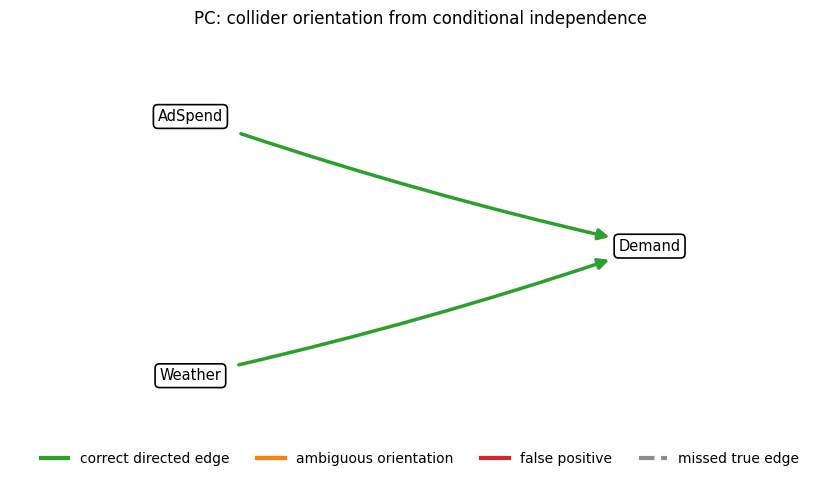

In [34]:
plot_causal_graph(NODES, POSITIONS, pred_edges, TRUE_EDGES, "PC: collider orientation from conditional independence")

Takeaway: PC is strongest when the teaching pattern is about conditional independence, especially collider orientation.